# Decode the Distance: Logical-Memory Decoding with Stim and PyMatching — reference solution

This notebook gives one compact solution. It is intended for maintainer review and for checking that the public challenge is feasible.


In [8]:
!python -m pip install -r requirements.txt

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 45.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 626.2/626.2 kB 36.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 69.7 MB/s eta 0:00:00


In [10]:
from __future__ import annotations

from typing import Any

import matplotlib.pyplot as plt
import numpy as np
import pymatching
import stim

import grader

SEED = 2026

try:
    get_ipython().run_line_magic("matplotlib", "inline")
except NameError:
    pass


## Task 1 solution — repetition-code syndrome

A syndrome fixes a correction chain up to a global bit flip. Starting with the first bit equal to 0 gives one chain; flipping every bit gives the other. The decoder returns the lower-weight chain.


In [11]:
def repetition_syndrome(error: np.ndarray) -> np.ndarray:
    e = grader.as_binary_array(error)
    if e.size < 2:
        raise ValueError("need at least two data bits")
    return np.bitwise_xor(e[:-1], e[1:]).astype(np.uint8)


def decode_repetition_syndrome(syndrome: np.ndarray) -> np.ndarray:
    s = grader.as_binary_array(syndrome)
    correction0 = np.zeros(s.size + 1, dtype=np.uint8)
    for i, bit in enumerate(s):
        correction0[i + 1] = correction0[i] ^ bit
    correction1 = 1 - correction0
    if int(correction1.sum()) < int(correction0.sum()):
        return correction1.astype(np.uint8)
    return correction0.astype(np.uint8)


print(grader.check_repetition_syndrome(repetition_syndrome))
print(grader.check_repetition_decoder(decode_repetition_syndrome))


check_repetition_syndrome passed
check_repetition_decoder passed


## Task 2 solution — memory circuits

The default experiments use rotated surface-code memories because they are small enough for a laptop while still using detector annotations and logical observables.


In [12]:
def make_memory_circuit(distance: int, rounds: int, p: float, basis: str = "z") -> stim.Circuit:
    if basis not in {"x", "z"}:
        raise ValueError("basis must be 'x' or 'z'")
    if distance < 3 or distance % 2 == 0:
        raise ValueError("distance must be an odd integer at least 3")
    if rounds < 1:
        raise ValueError("rounds must be positive")
    if not 0.0 <= p < 0.5:
        raise ValueError("p must be in [0, 0.5)")
    return stim.Circuit.generated(
        f"surface_code:rotated_memory_{basis}",
        distance=distance,
        rounds=rounds,
        before_round_data_depolarization=p,
        after_clifford_depolarization=p,
        after_reset_flip_probability=p,
        before_measure_flip_probability=p,
    )


example_circuit = make_memory_circuit(distance=3, rounds=3, p=0.001, basis="z")
print(example_circuit.num_qubits, example_circuit.num_detectors, example_circuit.num_observables)
print(grader.check_make_memory_circuit(make_memory_circuit))


26 24 1
check_make_memory_circuit passed


## Task 3 solution — build and apply a matching decoder

For `weighted=False`, the graph is kept but all detector-error probabilities are replaced by one value before constructing the decoder. This is a deliberately simple ablation, not a better decoder.


In [13]:
def build_matching(
    circuit: stim.Circuit,
    *,
    weighted: bool = True,
    uniform_probability: float = 0.01,
) -> pymatching.Matching:
    dem = circuit.detector_error_model(decompose_errors=True)
    if not weighted:
        dem = grader.replace_detector_error_probabilities(dem, probability=uniform_probability)
    return pymatching.Matching.from_detector_error_model(dem)


def sample_and_decode(
    circuit: stim.Circuit,
    matching: pymatching.Matching,
    shots: int,
    seed: int,
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    if shots <= 0:
        raise ValueError("shots must be positive")
    sampler = circuit.compile_detector_sampler(seed=seed)
    detector_events, observable_flips = sampler.sample(shots, separate_observables=True)
    predictions = matching.decode_batch(detector_events)
    return detector_events, observable_flips, predictions


def logical_failures(predictions: np.ndarray, observable_flips: np.ndarray) -> np.ndarray:
    pred = np.asarray(predictions, dtype=np.uint8)
    obs = np.asarray(observable_flips, dtype=np.uint8)
    if pred.ndim == 1:
        pred = pred[:, None]
    if obs.ndim == 1:
        obs = obs[:, None]
    if pred.shape != obs.shape:
        raise ValueError(f"shape mismatch: {pred.shape} != {obs.shape}")
    return np.any(pred != obs, axis=1)


print(grader.check_build_matching(build_matching))
print(grader.check_sample_and_decode(sample_and_decode))
print(grader.check_logical_failures(logical_failures))


check_build_matching passed
check_sample_and_decode passed
check_logical_failures passed


## Task 4 solution — logical error estimates

The Wilson interval is used because the default experiments sometimes have zero failures. A symmetric normal interval would report zero width in that case.


In [14]:
def wilson_interval(
    failures: int,
    shots: int,
    z: float = 1.959963984540054,
) -> tuple[float, float, float]:
    if shots <= 0:
        raise ValueError("shots must be positive")
    if failures < 0 or failures > shots:
        raise ValueError("failures must be between 0 and shots")
    phat = failures / shots
    denom = 1.0 + z * z / shots
    center = (phat + z * z / (2.0 * shots)) / denom
    radius = z * np.sqrt((phat * (1.0 - phat) + z * z / (4.0 * shots)) / shots) / denom
    return float(phat), float(max(0.0, center - radius)), float(min(1.0, center + radius))


def estimate_logical_error_rate(
    circuit: stim.Circuit,
    shots: int,
    seed: int,
    *,
    decoder_circuit: stim.Circuit | None = None,
    weighted: bool = True,
) -> dict[str, Any]:
    if decoder_circuit is None:
        decoder_circuit = circuit
    matching = build_matching(decoder_circuit, weighted=weighted)
    detector_events, observable_flips, predictions = sample_and_decode(circuit, matching, shots=shots, seed=seed)
    failures = logical_failures(predictions, observable_flips)
    failure_count = int(np.count_nonzero(failures))
    rate, ci_low, ci_high = wilson_interval(failure_count, shots)
    return {
        "shots": int(shots),
        "failures": failure_count,
        "rate": rate,
        "ci_low": ci_low,
        "ci_high": ci_high,
        "num_detectors": int(circuit.num_detectors),
        "num_observables": int(circuit.num_observables),
        "num_qubits": int(circuit.num_qubits),
    }


print(grader.check_wilson_interval(wilson_interval))
print(grader.check_zero_noise_pipeline(make_memory_circuit, estimate_logical_error_rate))
zero = estimate_logical_error_rate(make_memory_circuit(3, 3, 0.0), shots=256, seed=SEED)
print(zero)


check_wilson_interval passed
check_zero_noise_pipeline passed
{'shots': 256, 'failures': 0, 'rate': 0.0, 'ci_low': 0.0, 'ci_high': 0.01478385642587143, 'num_detectors': 24, 'num_observables': 1, 'num_qubits': 26}


## Task 5A solution — distance scaling

The default grid is small. It is enough to show the main qualitative point: below a low-noise regime, larger distance helps; at higher noise and short distances, the finite-size experiment can cross over.


In [15]:
def run_distance_grid(
    distances: list[int],
    p_values: list[float],
    shots: int,
    seed: int = SEED,
) -> list[dict[str, Any]]:
    rows: list[dict[str, Any]] = []
    for distance in distances:
        for p in p_values:
            circuit = make_memory_circuit(distance=distance, rounds=distance, p=p, basis="z")
            record = estimate_logical_error_rate(
                circuit,
                shots=shots,
                seed=seed + 10_000 * distance + int(round(1_000_000 * p)),
            )
            record.update({"distance": distance, "p": p, "rounds": distance})
            rows.append(record)
    return rows


distances = [3, 5, 7]
p_values = [0.001, 0.003, 0.006, 0.01, 0.02]
shots = 3000
records = run_distance_grid(distances, p_values, shots=shots)
for row in records:
    print(
        f"d={row['distance']} p={row['p']:.3g}: "
        f"{row['failures']}/{row['shots']} = {row['rate']:.4f} "
        f"[{row['ci_low']:.4f}, {row['ci_high']:.4f}]"
    )


d=3 p=0.001: 4/3000 = 0.0013 [0.0005, 0.0034]
d=3 p=0.003: 19/3000 = 0.0063 [0.0041, 0.0099]
d=3 p=0.006: 68/3000 = 0.0227 [0.0179, 0.0286]
d=3 p=0.01: 198/3000 = 0.0660 [0.0577, 0.0755]
d=3 p=0.02: 514/3000 = 0.1713 [0.1583, 0.1852]
d=5 p=0.001: 0/3000 = 0.0000 [0.0000, 0.0013]
d=5 p=0.003: 9/3000 = 0.0030 [0.0016, 0.0057]
d=5 p=0.006: 71/3000 = 0.0237 [0.0188, 0.0297]
d=5 p=0.01: 295/3000 = 0.0983 [0.0882, 0.1095]
d=5 p=0.02: 907/3000 = 0.3023 [0.2862, 0.3190]
d=7 p=0.001: 0/3000 = 0.0000 [0.0000, 0.0013]
d=7 p=0.003: 3/3000 = 0.0010 [0.0003, 0.0029]
d=7 p=0.006: 50/3000 = 0.0167 [0.0127, 0.0219]
d=7 p=0.01: 329/3000 = 0.1097 [0.0990, 0.1214]
d=7 p=0.02: 1239/3000 = 0.4130 [0.3955, 0.4307]


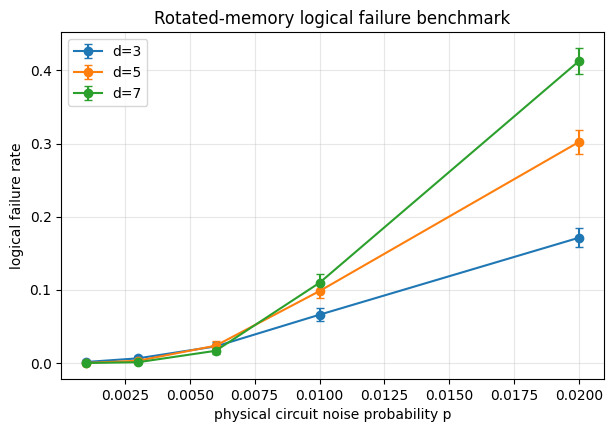

In [16]:
plt.figure(figsize=(7, 4.5))
for distance in distances:
    rows = [row for row in records if row["distance"] == distance]
    xs = np.asarray([row["p"] for row in rows])
    rates = np.asarray([row["rate"] for row in rows])
    lows = np.asarray([max(0.0, row["rate"] - row["ci_low"]) for row in rows])
    highs = np.asarray([max(0.0, row["ci_high"] - row["rate"]) for row in rows])
    plt.errorbar(xs, rates, yerr=np.vstack([lows, highs]), marker="o", capsize=3, label=f"d={distance}")
plt.xlabel("physical circuit noise probability p")
plt.ylabel("logical failure rate")
plt.title("Rotated-memory logical failure benchmark")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


## Task 5B solution — decoder mismatch stress test

The data-generating circuit below has asymmetric circuit-level noise. A decoder built from the true model is compared with a decoder built from a uniform model and with a decoder that ignores probability weights.


In [17]:
def make_asymmetric_memory_circuit(
    distance: int,
    rounds: int,
    *,
    gate: float,
    data: float,
    reset: float,
    measurement: float,
    basis: str = "z",
) -> stim.Circuit:
    if basis not in {"x", "z"}:
        raise ValueError("basis must be 'x' or 'z'")
    return stim.Circuit.generated(
        f"surface_code:rotated_memory_{basis}",
        distance=distance,
        rounds=rounds,
        after_clifford_depolarization=gate,
        before_round_data_depolarization=data,
        after_reset_flip_probability=reset,
        before_measure_flip_probability=measurement,
    )


def mismatch_experiment(shots: int = 5000, seed: int = SEED) -> list[dict[str, Any]]:
    true_circuit = make_asymmetric_memory_circuit(
        distance=5,
        rounds=5,
        gate=0.001,
        data=0.008,
        reset=0.001,
        measurement=0.0005,
    )
    uniform_circuit = make_memory_circuit(distance=5, rounds=5, p=0.003, basis="z")
    configs = [
        ("calibrated weighted", true_circuit, True),
        ("uniform weighted", uniform_circuit, True),
        ("unweighted graph", true_circuit, False),
    ]
    rows: list[dict[str, Any]] = []
    for label, decoder_circuit, weighted in configs:
        record = estimate_logical_error_rate(
            true_circuit,
            shots=shots,
            seed=seed,
            decoder_circuit=decoder_circuit,
            weighted=weighted,
        )
        record["decoder"] = label
        rows.append(record)
    return rows


mismatch_rows = mismatch_experiment()
for row in mismatch_rows:
    print(
        f"{row['decoder']:>20s}: {row['failures']}/{row['shots']} = {row['rate']:.4f} "
        f"[{row['ci_low']:.4f}, {row['ci_high']:.4f}]"
    )


 calibrated weighted: 4/5000 = 0.0008 [0.0003, 0.0021]
    uniform weighted: 6/5000 = 0.0012 [0.0006, 0.0026]
    unweighted graph: 46/5000 = 0.0092 [0.0069, 0.0122]


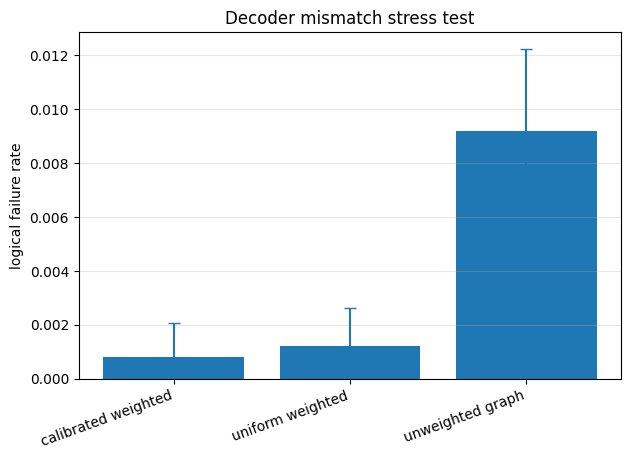

In [18]:
labels = [row["decoder"] for row in mismatch_rows]
rates = np.asarray([row["rate"] for row in mismatch_rows])
lows = np.asarray([max(0.0, row["rate"] - row["ci_low"]) for row in mismatch_rows])
highs = np.asarray([max(0.0, row["ci_high"] - row["rate"]) for row in mismatch_rows])

plt.figure(figsize=(7, 4.5))
plt.bar(labels, rates)
plt.errorbar(np.arange(len(labels)), rates, yerr=np.vstack([lows, highs]), fmt="none", capsize=4)
plt.ylabel("logical failure rate")
plt.title("Decoder mismatch stress test")
plt.xticks(rotation=20, ha="right")
plt.grid(True, axis="y", alpha=0.3)
plt.show()


## Interpretation and limitations

The benchmark is intentionally small. With a few thousand shots, zero observed failures only gives an upper bound, not proof of zero logical error. The weighted decoder also relies on the detector error model matching the data source. When the physical noise is correlated or badly calibrated, MWPM on an independent graphlike model can be the wrong abstraction.

This challenge does not ask for threshold estimation at publication precision. It asks for a controlled, reproducible logical-memory benchmark with explicit uncertainty.


In [19]:
# Final public checks.
print(grader.check_repetition_syndrome(repetition_syndrome))
print(grader.check_repetition_decoder(decode_repetition_syndrome))
print(grader.check_make_memory_circuit(make_memory_circuit))
print(grader.check_build_matching(build_matching))
print(grader.check_sample_and_decode(sample_and_decode))
print(grader.check_logical_failures(logical_failures))
print(grader.check_wilson_interval(wilson_interval))
print(grader.check_zero_noise_pipeline(make_memory_circuit, estimate_logical_error_rate))
grader.run_smoke_tests()


check_repetition_syndrome passed
check_repetition_decoder passed
check_make_memory_circuit passed
check_build_matching passed
check_sample_and_decode passed
check_logical_failures passed
check_wilson_interval passed
check_zero_noise_pipeline passed
check_repetition_syndrome passed
check_repetition_decoder passed
check_make_memory_circuit passed
check_build_matching passed
check_sample_and_decode passed
check_logical_failures passed
check_wilson_interval passed
check_zero_noise_pipeline passed
